# Thief Detector
## This task tests your Image Processing skills to build a motion detection algorithm that alarms you when you have an unwanted visitor in your home.

## Steps
- 1. Get the live video feed from your webcam
- 2. Fix a scene (the place you want to monitor) and store it as a reference background image
    - Store the first frame as the reference background frame
- 3. For every frame, check if there is any unwanted object inside the scene you are monitoring
    - Use **Background Subtraction** concept (**cv2.absdiff( )**)
        - Subtract the current frame from the reference background image(frame) to see the changes in the scene
        - If there is enormous amount of pixels distrubed in the subtraction result image
            - unwanted visitor (place is unsafe --> alarm the authorities)
        - If there is no enormous amount of pixels distrubed in the subtraction result image
            - no unwanted visitor (place is safe)
- 4. Output the text **"UNSAFE"** in **red** color on the top right of the frame when there is an intruder in the scene.
- 5. Save the live feed
- 6. Submit the (.ipynb) file

## Get live video feed from webcam [10 points]

In [19]:
pip install opencv-python

## Read first frame, convert to Grayscale and store it as reference background image [10 points]

In [20]:
import cv2
import numpy as np
import os
import time
from datetime import datetime

# Initialize the webcam
cap = cv2.VideoCapture(0)  # 0 for the default webcam

# Check if the webcam is opened correctly
if not cap.isOpened():
    print("Error: Could not open webcam.")
    exit()

# Set the frame rate (frames per second) to 50 instead of the default 30
cap.set(cv2.CAP_PROP_FPS, 50)

# Get the current time to determine the end time (30 seconds later)
start_time = time.time()
end_time = start_time + 30  # 30 seconds (1/2 minute)

# Get the path to the Downloads folder (adjust if necessary)
downloads_folder = os.path.expanduser('~') + "/Downloads/"
if not os.path.exists(downloads_folder):
    print("Downloads folder not found!")
    exit()

# Set the video file name with a timestamp
video_filename = f"motion_detection_{datetime.now().strftime('%Y%m%d_%H%M%S')}.avi"
video_filepath = os.path.join(downloads_folder, video_filename)

# Define the codec and create the VideoWriter object
fourcc = cv2.VideoWriter_fourcc(*'XVID')
out = cv2.VideoWriter(video_filepath, fourcc, 10.0, (640, 480))  # 10 FPS for video output

print(f"Recording video to: {video_filepath}")

# Capture the first frame and store it as the reference background image
ret, first_frame = cap.read()
if not ret:
    print("Error: Could not read first frame.")
    exit()

Recording video to: C:\Users\Owner/Downloads/motion_detection_20241122_210841.avi


## Compute Absolute Difference between Current and First frame [20 points]

In [21]:
first_frame_gray = cv2.cvtColor(first_frame, cv2.COLOR_BGR2GRAY)
first_frame_gray = cv2.GaussianBlur(first_frame_gray, (21, 21), 0)

frame_count = 0
motion_detected_count = 0  # To track how many frames have motion detected

while time.time() < end_time:
    # Capture the current frame from the webcam
    ret, frame = cap.read()
    if not ret:
        print("Failed to access the webcam.")
        break

## Apply threshold [5 points]

In [22]:
gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

# Apply Gaussian blur to reduce noise
gray = cv2.GaussianBlur(gray, (21, 21), 0)

# Compute the absolute difference between the current frame and the first frame
delta_frame = cv2.absdiff(first_frame_gray, gray)

# Apply thresholding to the difference image to focus on significant motion
thresh_frame = cv2.threshold(delta_frame, 30, 255, cv2.THRESH_BINARY)[1]
    
# Use morphological operations (dilation) to improve the mask
thresh_frame = cv2.dilate(thresh_frame, None, iterations=2)

## Find contours [10 points]

In [23]:
contours, _ = cv2.findContours(thresh_frame.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

## Check if contourArea is large and draw rectangle around the object, output "UNSAFE" text in red color [30 points]

In [ ]:
motion_detected = 0

    # Loop through detected contours
    for contour in contours:
        if cv2.contourArea(contour) < 500:  # Ignore small contours (adjust as needed)
            continue
        motion_detected = 1
        (x, y, w, h) = cv2.boundingRect(contour)
        cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 255, 0), 2)  # Draw bounding box
        cv2.putText(frame, "UNSAFE", (x + w - 100, y + 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2, cv2.LINE_AA)

## Display images [10 points]

Recording video to: C:\Users\Owner/Downloads/motion_detection_20241122_212227.avi


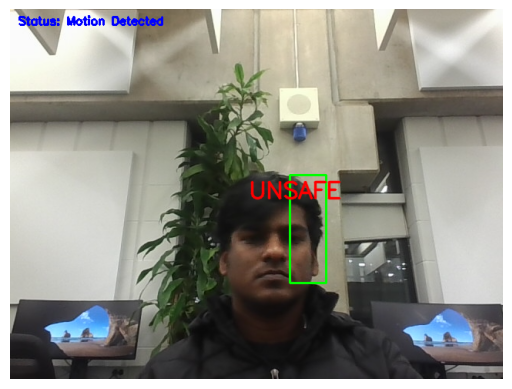

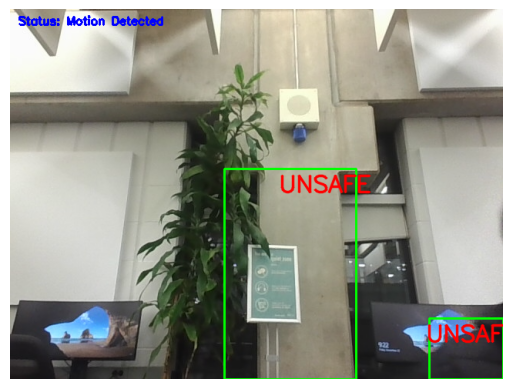

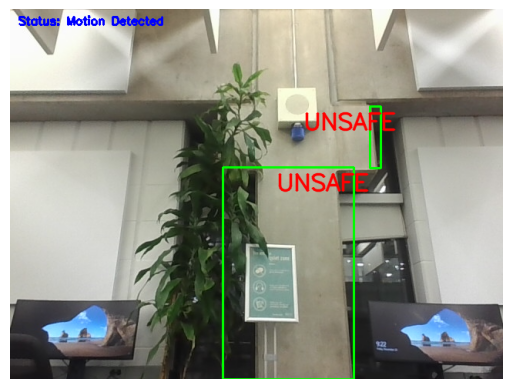

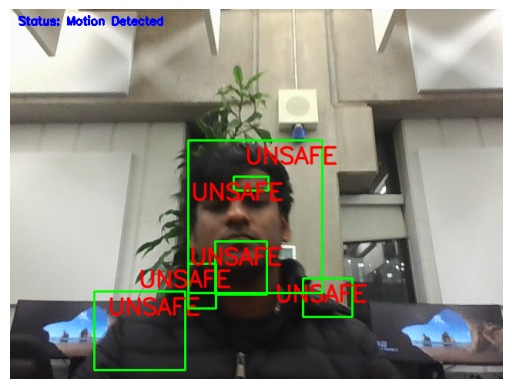

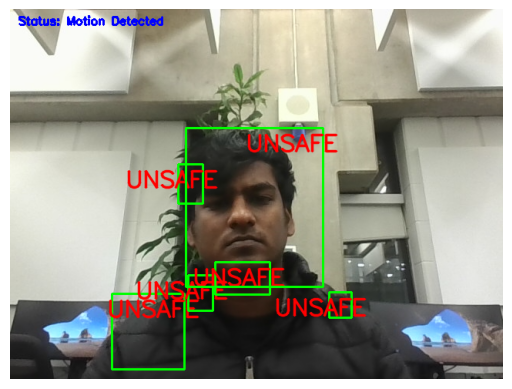

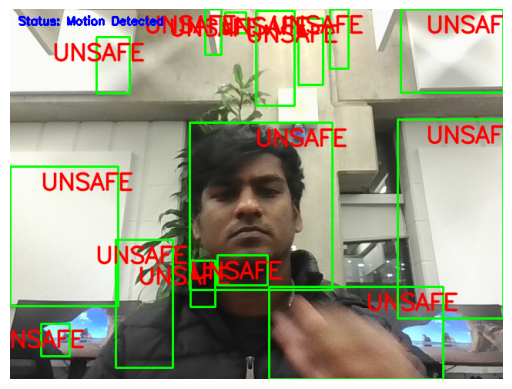

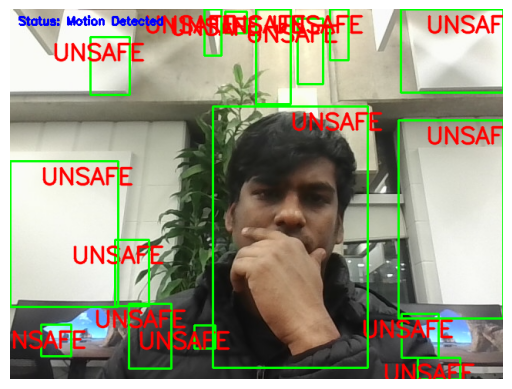

Video saved to: C:\Users\Owner/Downloads/motion_detection_20241122_212227.avi


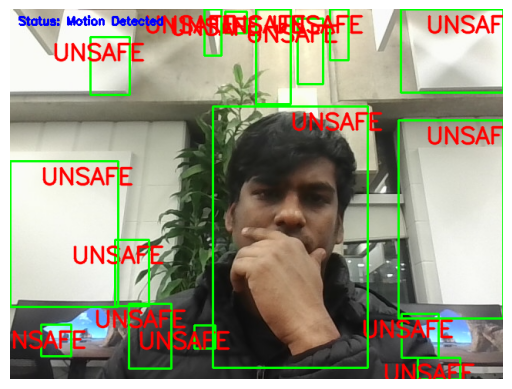

In [29]:
# Display the status on the frame
    status_text = "Motion Detected" if motion_detected else "No Motion"
    cv2.putText(frame, f"Status: {status_text}", (10, 20), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)

    # Write the frame to the video output file
    out.write(frame)

    # Count the frame if motion was detected
    if motion_detected:
        motion_detected_count += 1
        # Convert the frame to RGB (OpenCV uses BGR by default)
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        # Display the image in the notebook
        plt.imshow(frame_rgb)
        plt.axis('off')  # Hide axes
        display(plt.gcf())  # Display the current frame

    # Show the live video feed (optional)
    cv2.imshow('Motion Detection', frame)

    # Increment the frame counter
    frame_count += 1



## Release objects [5 points]

In [25]:
cap.release()
out.release()

# Close all OpenCV windows
cv2.destroyAllWindows()

# Calculate accuracy
if frame_count > 0:
    accuracy = (motion_detected_count / frame_count) * 100
    print(f"Motion detection accuracy: {accuracy:.2f}%")
else:
    print("No frames were processed.")

print(f"Video saved to: {video_filepath}")

Recording video to: C:\Users\Owner/Downloads/motion_detection_20241122_211013.avi
Motion detection accuracy: 99.31%
Video saved to: C:\Users\Owner/Downloads/motion_detection_20241122_211013.avi
